# **Kutubxonalarni yuklash**


In [576]:
!pip install catboost

In [577]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    RocCurveDisplay,
    roc_auc_score
)

# **Ma'lumotlarni o'rganish**

In [578]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [579]:
df_train.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15702656.0,Nwora,567.0,France,Male,33.0,9.0,0.0,2.0,1.0,0.0,156792.89,0.0
1,1,15647965.0,Yevdokimova,628.0,France,Female,38.0,3.0,0.0,1.0,1.0,1.0,51987.99,1.0
2,2,15798834.0,Ch'iu,635.0,France,Female,29.0,3.0,0.0,2.0,1.0,1.0,113079.19,0.0
3,3,15672056.0,Hsia,681.0,France,Male,28.0,6.0,0.0,2.0,1.0,0.0,14081.64,0.0
4,4,15759537.0,Okwudilichukwu,587.0,France,Female,27.0,5.0,0.0,2.0,1.0,0.0,158958.90,0.0


In [580]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [581]:
df_train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.579454e+07,657.856800,37.710133,5.018667,42338.107539,1.590533,0.779133,0.496000,116944.059867,0.198467
std,4330.271354,1.268495e+07,72.678739,8.144880,2.787407,59703.047751,0.525822,0.414845,0.500001,46047.485455,0.398859
min,0.000000,1.567151e+05,431.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3749.750000,1.563435e+07,602.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,82644.332500,0.000000
50%,7499.500000,1.568947e+07,661.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,122449.420000,0.000000
75%,11249.250000,1.575682e+07,707.000000,42.000000,7.000000,109636.342500,2.000000,1.000000,1.000000,155703.022500,0.000000
max,14999.000000,1.569172e+09,850.000000,72.000000,10.000000,187911.550000,5.000000,1.000000,1.000000,885120.790000,1.000000


In [582]:
for i in ['Geography', 'Gender', 'Tenure', 'HasCrCard', 'IsActiveMember', 'Exited']:
  print(df_train[i].value_counts())

Geography
France     9040
Spain      3280
Germany    2680
Name: count, dtype: int64
Gender
Male      8478
Female    6522
Name: count, dtype: int64
Tenure
7.0     1658
3.0     1647
2.0     1624
8.0     1574
9.0     1560
5.0     1559
1.0     1518
4.0     1516
6.0     1451
10.0     477
0.0      416
Name: count, dtype: int64
HasCrCard
1.0    11687
0.0     3313
Name: count, dtype: int64
IsActiveMember
0.0    7560
1.0    7440
Name: count, dtype: int64
Exited
0.0    12023
1.0     2977
Name: count, dtype: int64


In [583]:
df_train.duplicated().sum()

np.int64(0)

In [584]:
df_train.isnull().sum()

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [585]:
df_train.drop(columns=['id', 'CustomerId', 'Surname'], inplace=True)

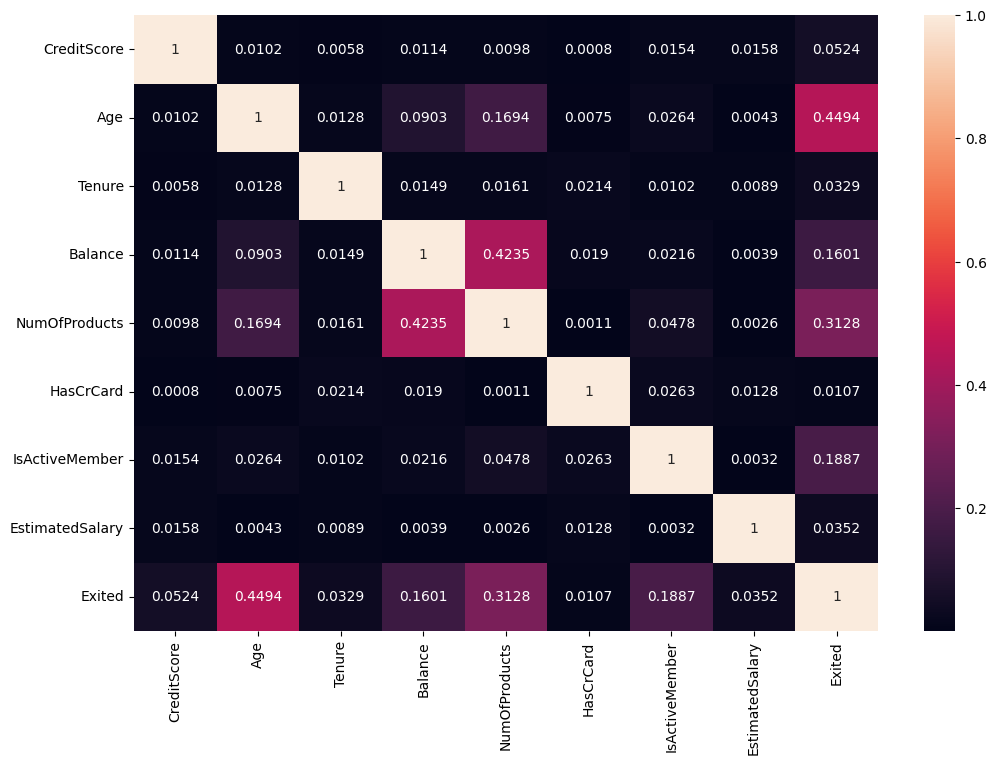

In [586]:
plt.figure(figsize=(12, 8))
df_corr = df_train.select_dtypes(include='number').corr().abs().round(4)
sns.heatmap(data=df_corr, annot=True, fmt='g')
plt.xticks(rotation=90)
plt.show()

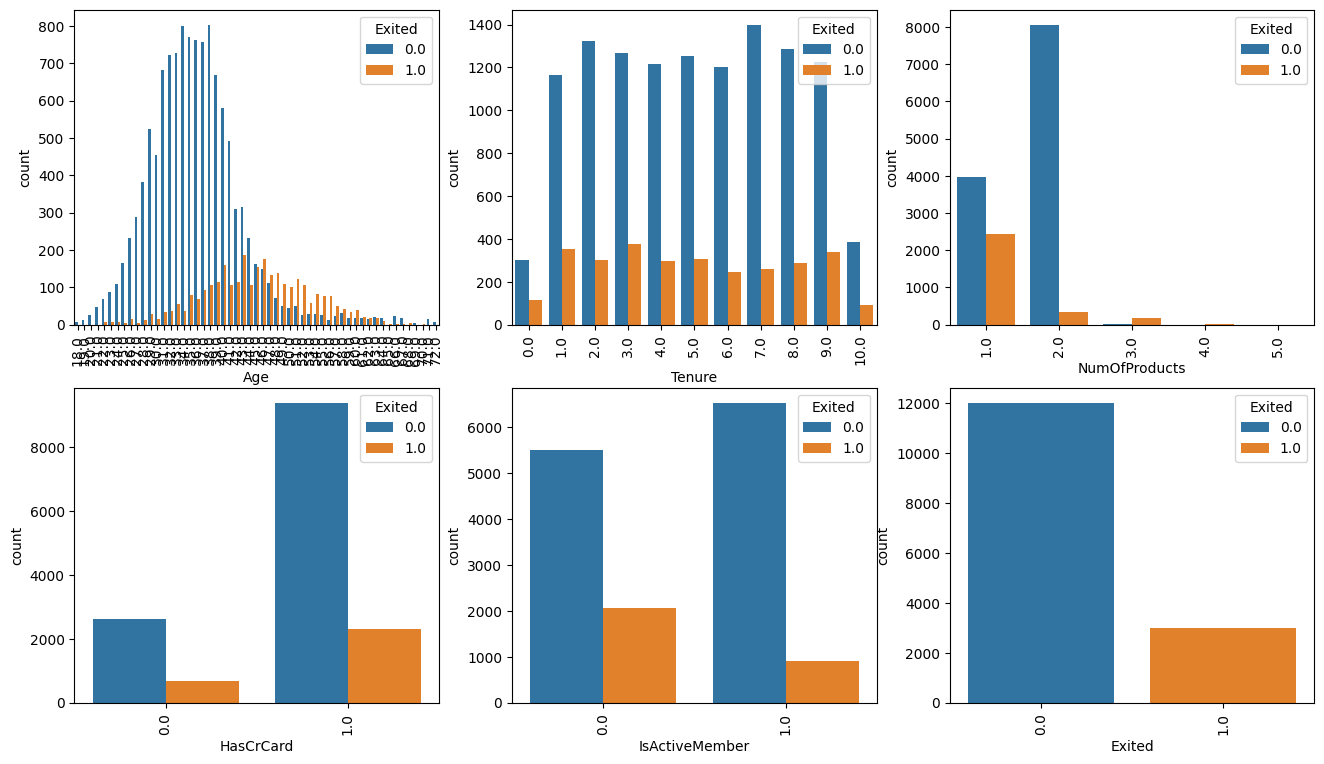

In [587]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
cols = df_train.select_dtypes(include='number').columns.drop(["Balance", "CreditScore", 'EstimatedSalary'])

for ax, col in zip(axes, cols):
  sns.countplot(data=df_train, x=col, hue='Exited', ax=ax)
  ax.tick_params(axis='x', rotation=90)

plt.show()

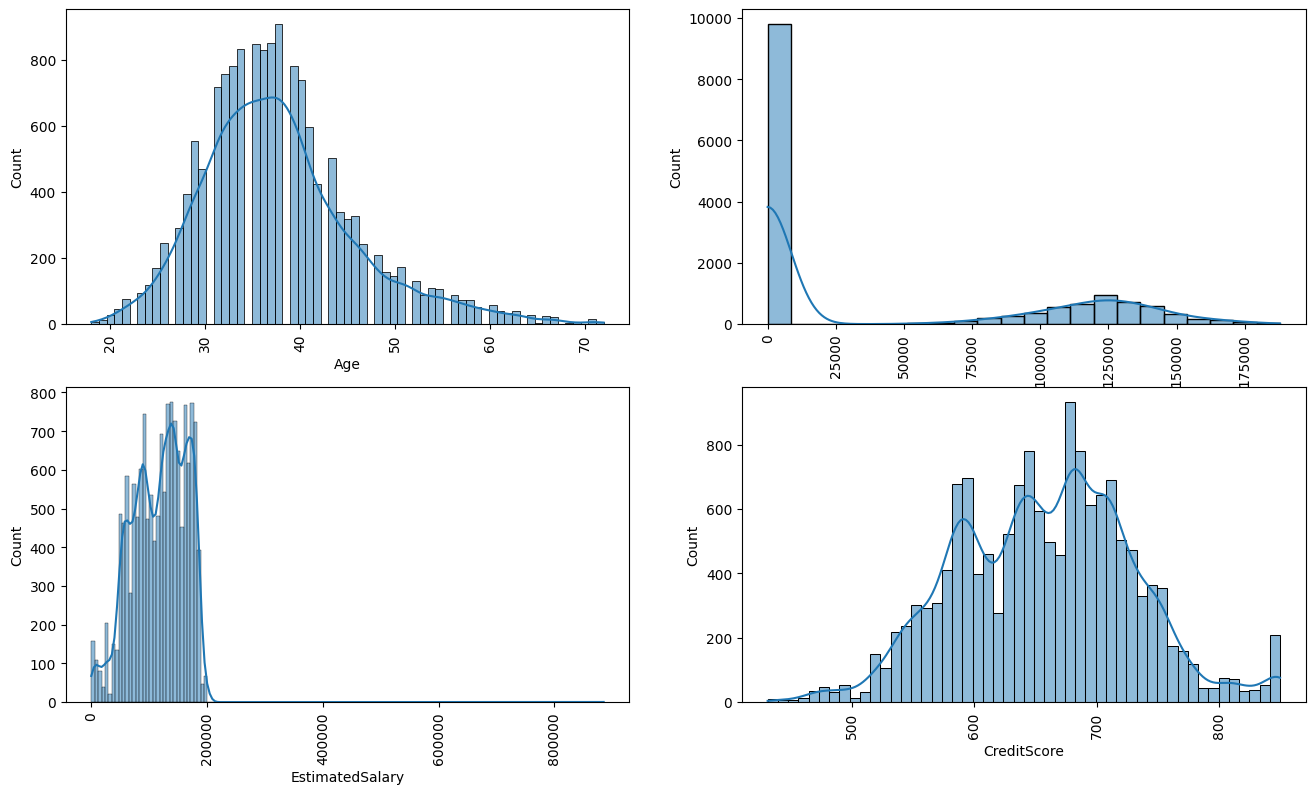

In [588]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
cols = ["Age", 'Balance', 'EstimatedSalary', 'CreditScore']

for ax, col in zip(axes, cols):
  sns.histplot(data=df_train, x=col,kde=True, ax=ax)
  ax.tick_params(axis='x', rotation=90)
plt.show()

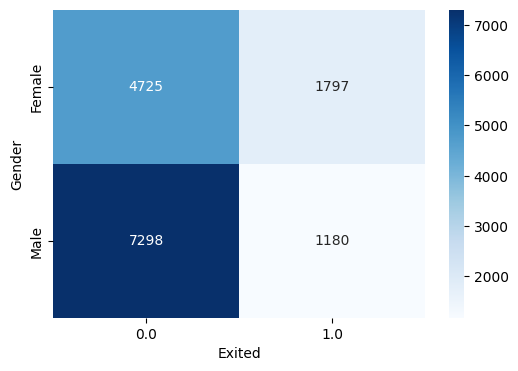

In [589]:
plt.figure(figsize=(6, 4))
Gender_Ex = pd.crosstab(df_train['Gender'], df_train['Exited'])
sns.heatmap(Gender_Ex, annot=True, fmt='d', cmap="Blues")
plt.show()

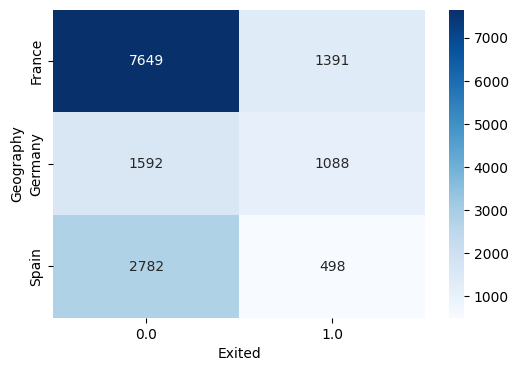

In [590]:
plt.figure(figsize=(6, 4))
Geography_Ex = pd.crosstab(df_train['Geography'], df_train['Exited'])
sns.heatmap(Geography_Ex, annot=True, fmt='d', cmap="Blues")
plt.show()

# **Ma'lumotlarni tayyorlash**

In [591]:
X = df_train.drop(columns=['Exited'])
y = df_train['Exited'].copy()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

In [592]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
cat_cols = ['Geography', 'Gender']
bin_cols = ['HasCrCard', 'IsActiveMember']

pipeline = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ("bin", "passthrough", bin_cols)
])


X_train_p = pipeline.fit_transform(X_train)
X_val_p = pipeline.transform(X_val)

In [593]:
def confusion_matrix_plot(y_val, y_pred):
  confus_mat = confusion_matrix(y_val, y_pred)
  return sns.heatmap(confus_mat, annot=True, fmt='d', cmap="Blues")

def model_metrics(y_val, y_pred):
  return {
          "Accuracy": accuracy_score(y_val, y_pred),
          "Precision": precision_score(y_val, y_pred),
          "Recall": recall_score(y_val, y_pred),
          "F1": f1_score(y_val, y_pred)
  }

In [594]:
def evaluate_model(model, X_val_p, y_val, model_name):
    y_pred = model.predict(X_val_p)

    confusion_matrix_plot(y_val, y_pred)
    plt.xlabel("Bashorat")
    plt.ylabel("Haqiqiy")
    plt.title("Confusion Matrix")
    plt.show()

    print(model_metrics(y_val, y_pred))

    y_prob = model.predict_proba(X_val_p)[:,1]
    fpr, tpr, thresholds = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=model_name)
    display.plot()
    plt.show()

    print("ROC AUC:", roc_auc)

# **Model qurish**


*   ## **Logistic Regression**

In [595]:
model_LR = LogisticRegression(class_weight='balanced') # Roc_auc -> class_weight=none:  0.8838, class_weight='balanced': 0.8854
model_LR.fit(X_train_p, y_train)

LogisticRegression(class_weight='balanced')

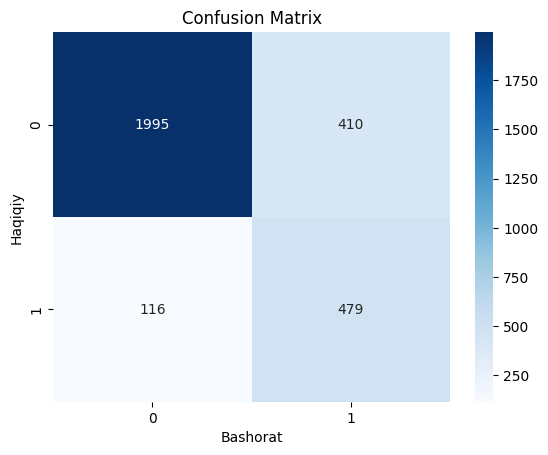

{'Accuracy': 0.8246666666666667, 'Precision': 0.5388076490438695, 'Recall': 0.8050420168067227, 'F1': 0.6455525606469003}


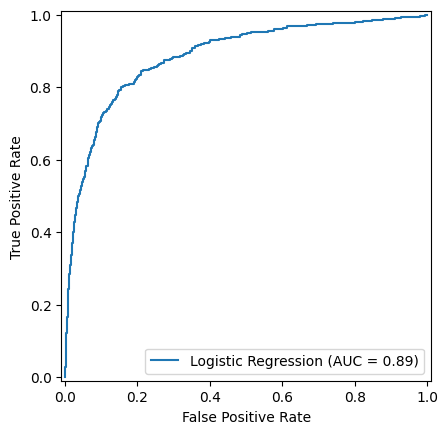

ROC AUC: 0.8854424430895019


In [596]:
evaluate_model(model_LR, X_val_p, y_val, model_name="Logistic Regression")

# **Model qurish**


*   ## **Decision Tree**

In [597]:
model_DT = DecisionTreeClassifier(max_depth=5) # Roc-auc -> defoult: 0.7704, max_depth=5: 0.9126, max_depth=10: 0.8546, max_depth=2: 0.8273, max_depth=7: 0.9079; min_samples_leaf gipermarametrini 30gacha test qilib kordim lekin 0.901 oarsida natija berdi lekin model optimali max_depth=5 bo'lganda ham bundan yaxshi natijani berdi
model_DT.fit(X_train_p, y_train)

DecisionTreeClassifier(max_depth=5)

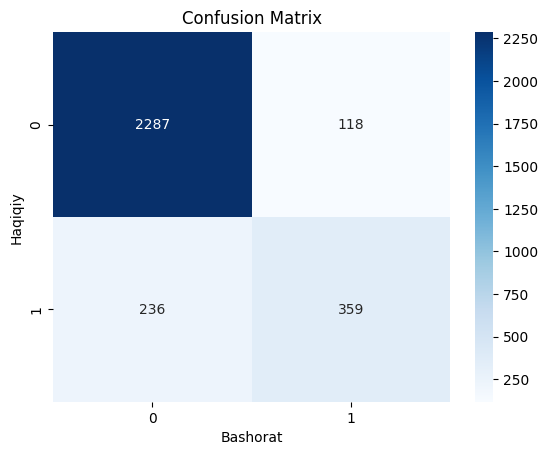

{'Accuracy': 0.882, 'Precision': 0.7526205450733753, 'Recall': 0.6033613445378151, 'F1': 0.6697761194029851}


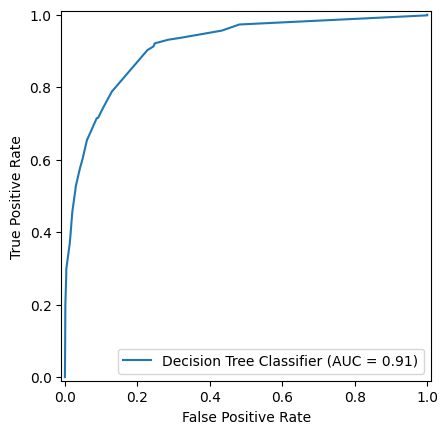

ROC AUC: 0.9126015478956656


In [598]:
evaluate_model(model_DT, X_val_p, y_val, model_name='Decision Tree Classifier')

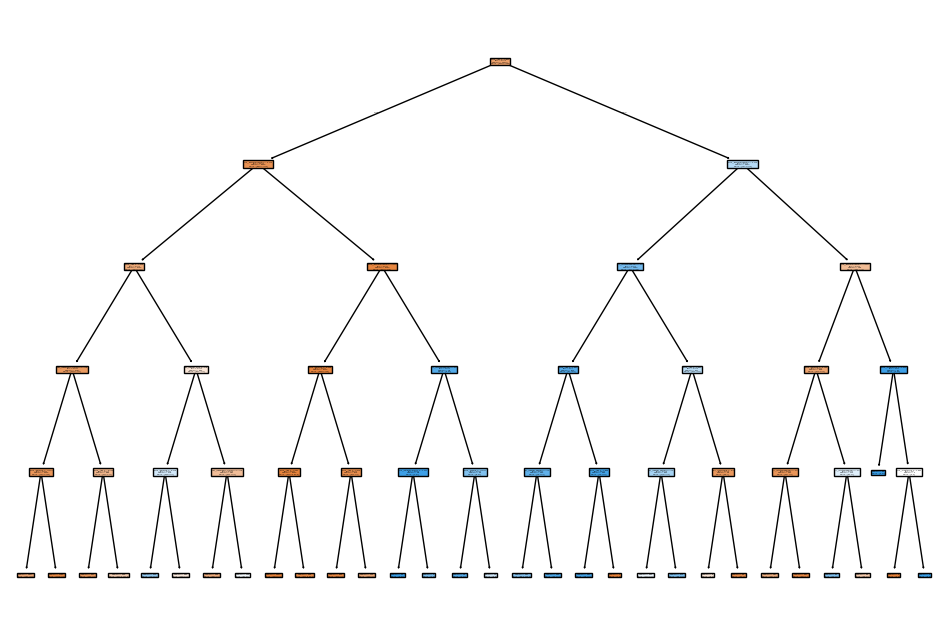

In [599]:
plt.figure(figsize=(12, 8))
plot_tree(model_DT, feature_names=pipeline.get_feature_names_out(), filled=True)
plt.show()

# **Model qurish**

*   ## **Random Forest**




In [600]:
model_RF = RandomForestClassifier(random_state=42, max_depth=10) # roc_auc -> defoult: 0.9205, n_est=200: 0.9236, n_est=400: 0.9227, n_est=300: 0.9243; max_depth=5: 0.9255, max_depth=10: 0.9312, max_depth=12: 0.9275; min_s_l=2: 0.9269, min_s_l=4: 0.9280; max_depth=10, n_estimators=300: 0.9304
model_RF.fit(X_train_p, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

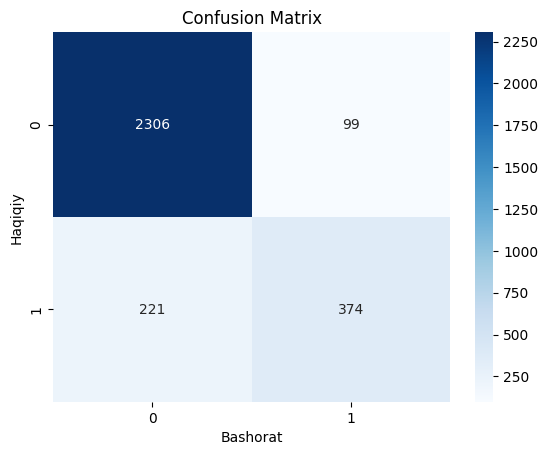

{'Accuracy': 0.8933333333333333, 'Precision': 0.7906976744186046, 'Recall': 0.6285714285714286, 'F1': 0.700374531835206}


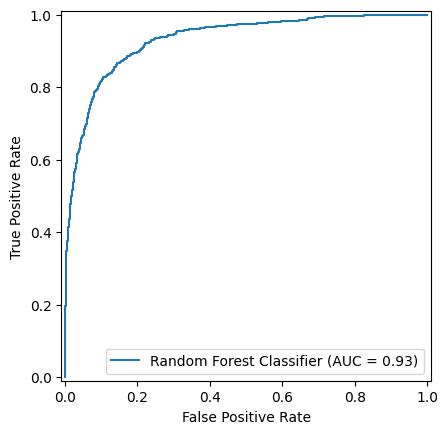

ROC AUC: 0.9314663079368962


In [601]:
evaluate_model(model_RF, X_val_p, y_val, model_name="Random Forest Classifier")

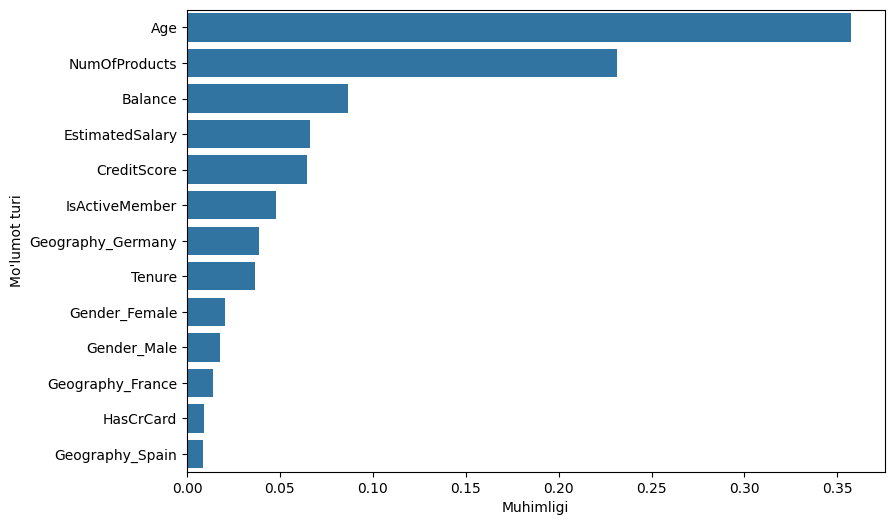

In [602]:
importances = pd.DataFrame()
cols_name = [i.split('__')[1] for i in pipeline.get_feature_names_out()]
importances['Features'] = cols_name
importances['Importance'] = model_RF.feature_importances_
importances = importances.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(9,6))
sns.barplot(data=importances, x="Importance", y="Features")
plt.xlabel("Muhimligi")
plt.ylabel("Mo'lumot turi")
plt.show()

# **Model qurish**

*   ## **XGBoost**




In [603]:
model_XGB = XGBClassifier(random_state=42, max_depth=5)# roc_auc -> n_ast=100 > n_ast=200. max_depth=5: 0.928, max_depth=10: 0.918, max_depth=15: 0.915.
model_XGB.fit(X_train_p, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

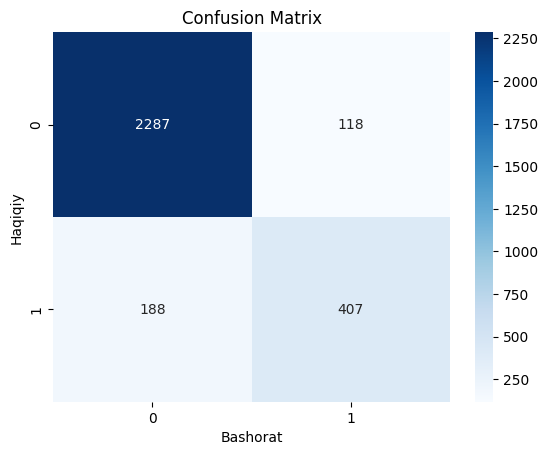

{'Accuracy': 0.898, 'Precision': 0.7752380952380953, 'Recall': 0.6840336134453782, 'F1': 0.7267857142857143}


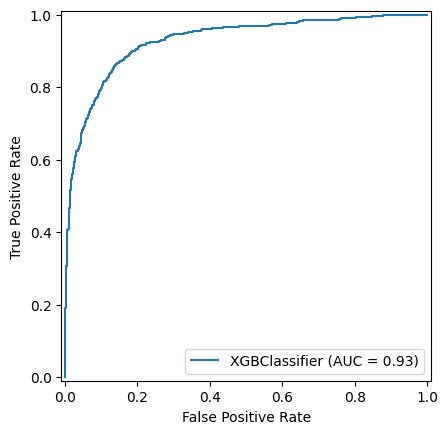

ROC AUC: 0.9284788343611873


In [604]:
evaluate_model(model_XGB, X_val_p, y_val, model_name='XGBClassifier')

# **Model qurish**

*   ## **CatBoost**




In [605]:
model_CBC = CatBoostClassifier(random_state=42,max_depth=4, learning_rate=0.01, verbose=False) # roc_auc depth=none: 0.931, depth=5, 0.932, depth=10, 0.924, depth=2, 0.932, depth=3: 0.933, depth=4: 0.933, lr_rate=0.01: 0.9339, lr_rate=0.001: 0.927, lr_rate=0.02: 0.9335, lr=0.03: 0.923, max_depth=4, learning_rate=0.01: 0.934
model_CBC.fit(X_train_p, y_train)

CatBoostClassifier(learning_rate=0.01, max_depth=4, random_state=42, verbose=False)

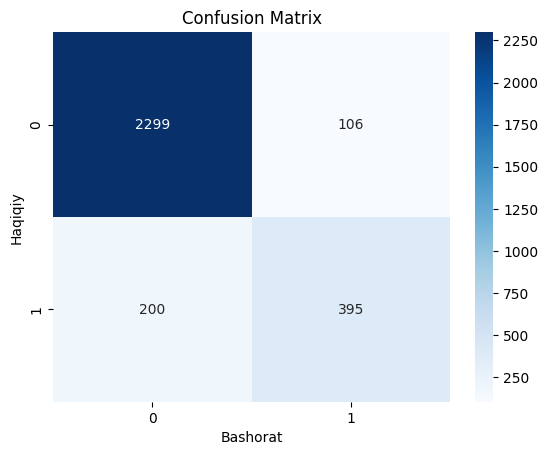

{'Accuracy': 0.898, 'Precision': 0.7884231536926147, 'Recall': 0.6638655462184874, 'F1': 0.7208029197080292}


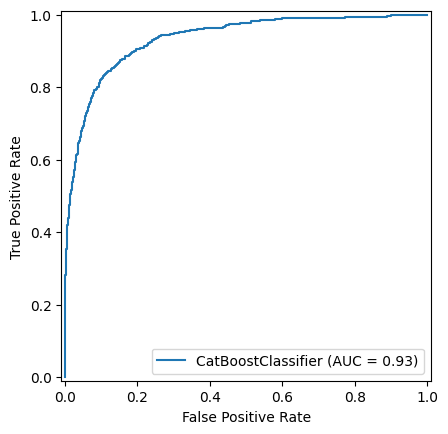

ROC AUC: 0.9340079316549904


In [606]:
evaluate_model(model_CBC, X_val_p, y_val, model_name='CatBoostClassifier')

# **Modellarni taqqoslash**

In [607]:
models = {
    "Logistic Regression": model_LR,
    "Decision Tree": model_DT,
    "Random Forest": model_RF,
    "XGBoost": model_XGB,
    "CatBoost": model_CBC
}
results = []

for name, model in models.items():
  y_pred = model.predict(X_val_p)
  y_prob = model.predict_proba(X_val_p)[:,1]

  results.append({
      "Model": name,
      "Accuracy": accuracy_score(y_val, y_pred),
      "Precision": precision_score(y_val, y_pred),
      "Recall": recall_score(y_val, y_pred),
      "F1": f1_score(y_val, y_pred),
      "Roc Auc": roc_auc_score(y_val, y_prob)
  })

models_choice = pd.DataFrame(results)
model_choice = models_choice.sort_values(by="Roc Auc", ascending=False).reset_index(drop=True)
model_choice

,Model,Accuracy,Precision,Recall,F1,Roc Auc
0,CatBoost,0.898000,0.788423,0.663866,0.720803,0.934008
1,Random Forest,0.893333,0.790698,0.628571,0.700375,0.931466
2,XGBoost,0.898000,0.775238,0.684034,0.726786,0.928479
3,Decision Tree,0.882000,0.752621,0.603361,0.669776,0.912602
4,Logistic Regression,0.824667,0.538808,0.805042,0.645553,0.885442


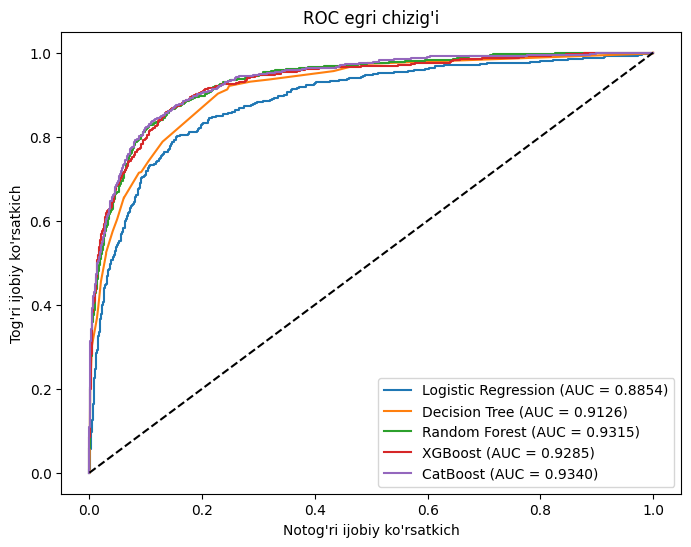

In [608]:
plt.figure(figsize=(8,6))
for model_name, model in models.items():
  y_prob = model.predict_proba(X_val_p)[:,1]
  fpr, tpr, thresholds = roc_curve(y_val, y_prob)
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Notog'ri ijobiy ko'rsatkich")
plt.ylabel("Tog'ri ijobiy ko'rsatkich")
plt.title("ROC egri chizig'i")
plt.legend(loc="lower right")
plt.show()


# **Xulosa**

*Ushbu loyiha uchun Logistic Regression, Decision Tree, Random Forest, XGBoost va CatBoost modellari qurdim va o‘zaro taqqosladim. Natijalarga ko‘ra, CatBoost modeli ROC-AUC bo‘yicha eng yuqori natijani ko‘rsatdi. Shuning uchun ushbu vazifa uchun CatBoost modeli eng yaxshi yechim deb tanlandim va testni o'tkazdim.*

# **Modelni test qilish**

In [609]:
df_test_model = df_test.drop(columns=['id', 'CustomerId', 'Surname'])
X_test_p = pipeline.transform(df_test_model)

In [610]:
test_prob = model_CBC.predict_proba(X_test_p)[:,1]

submission = pd.DataFrame()
submission['id'] = df_test['id']
submission['Exited'] = test_prob.round(2)


submission.to_csv('submission.csv', index=False)
submission.head()

,id,Exited
0,15000,0.04
1,15001,0.15
2,15002,0.04
3,15003,0.13
4,15004,0.01
